# Ablation Study: Autoregressive Decoder — EXTENDED (Strong Augmentation)

**PhD Thesis — Diana Paola Ayala Roldán**

Fine-tunes from the basic run checkpoint (`best.pth`) with aggressive augmentation:
- Geometric: rotation, vertical flip, random scale
- Skin tone: HSV hue/sat/value shifts (Fitzpatrick I-VI coverage)
- Noise: Gaussian noise + blur, contrast jitter

**Architecture:** ResNet-50 + Transformer → Autoregressive decoder
**Protocol:** Load pretrained → 30 epochs fine-tuning @ lr=3e-5
**Runtime:** ~2-4h on Kaggle T4 GPU

## 0. Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'einops'])

import os
import json
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Output dirs ──────────────────────────────────────────────────────────────
for d in ['results/ablation/polar', 'results/ablation/detr',
          'results/ablation/autoregressive', 'figures']:
    Path(d).mkdir(parents=True, exist_ok=True)

print('\nSetup complete.')

PyTorch : 2.10.0+cpu
Device  : cpu

Setup complete.


## 1. Synthetic Dataset Generator

> **Why 64 radii?**  
> Angular resolution = 360°/64 = **5.625° per sample**.  
> For a wound contour with maximum spatial frequency *f* cycles/revolution, the Nyquist criterion requires N > 2f.  
> Empirical wound shapes rarely exceed 10-15 cycles/revolution (StarDist uses 32-64).  
> 64 balances expressiveness vs. regression difficulty — validated in Schmidt et al. (2018) and Neven et al. (2019).

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SYNTHETIC GENERATOR  (self-contained, no external module needed)
# Generates star-convex wound-like shapes with realistic texture
# ─────────────────────────────────────────────────────────────────────────────

NUM_RADII   = 64          # polar representation resolution
IMAGE_SIZE  = 256

def generate_star_convex_wound(image_size=IMAGE_SIZE, num_radii=NUM_RADII, rng=None):
    """Generate one synthetic wound sample.

    Returns dict with:
      image     : (H, W, 3) uint8
      mask      : (H, W)    uint8  binary
      centroid  : (2,)      float  normalised [0,1]
      radii     : (num_radii,) float normalised [0,1]
      points    : (num_radii, 2) float normalised [0,1] boundary pts
    """
    if rng is None:
        rng = np.random

    H = W = image_size
    cx = rng.uniform(0.35, 0.65)
    cy = rng.uniform(0.35, 0.65)

    # ── Star-convex boundary via smoothed random radii ────────────────────
    angles = np.linspace(0, 2*np.pi, num_radii, endpoint=False)
    base_r = rng.uniform(0.12, 0.28)
    # low-frequency perturbation (5–8 harmonics, like real wounds)
    n_harmonics = rng.randint(3, 8)
    r = np.ones(num_radii) * base_r
    for k in range(1, n_harmonics+1):
        amp   = rng.uniform(0, base_r * 0.3 / k)
        phase = rng.uniform(0, 2*np.pi)
        r += amp * np.cos(k * angles + phase)
    r = np.clip(r, 0.04, 0.45)

    # boundary points in image coords
    pts_x = cx + r * np.cos(angles)
    pts_y = cy + r * np.sin(angles)
    pts_x = np.clip(pts_x, 0.01, 0.99)
    pts_y = np.clip(pts_y, 0.01, 0.99)

    # ── Background skin texture ───────────────────────────────────────────
    skin_r = int(rng.uniform(180, 220))
    skin_g = int(rng.uniform(130, 170))
    skin_b = int(rng.uniform(100, 140))
    noise  = rng.randint(-15, 15, (H, W, 3)).astype(np.int16)
    img    = np.clip(
        np.array([[[skin_r, skin_g, skin_b]]], dtype=np.int16) + noise,
        0, 255).astype(np.uint8)

    # ── Fill wound region ─────────────────────────────────────────────────
    mask = np.zeros((H, W), dtype=np.uint8)
    poly = np.stack([pts_x * W, pts_y * H], axis=1).astype(np.int32)

    # rasterise polygon
    from PIL import Image as PILImage, ImageDraw
    mask_pil = PILImage.fromarray(mask)
    draw = ImageDraw.Draw(mask_pil)
    draw.polygon([tuple(p) for p in poly], fill=255)
    mask = np.array(mask_pil)

    wound_r = int(rng.uniform(140, 190))
    wound_g = int(rng.uniform(50, 100))
    wound_b = int(rng.uniform(50, 90))
    wound_noise = rng.randint(-20, 20, (H, W, 3)).astype(np.int16)
    wound_color = np.clip(
        np.array([[[wound_r, wound_g, wound_b]]], dtype=np.int16) + wound_noise,
        0, 255).astype(np.uint8)
    img[mask > 0] = wound_color[mask > 0]

    return {
        'image'   : img,
        'mask'    : mask,
        'centroid': np.array([cx, cy], dtype=np.float32),
        'radii'   : r.astype(np.float32),
        'points'  : np.stack([pts_x, pts_y], axis=1).astype(np.float32),
    }


def generate_dataset(output_dir, num_samples=2000, seed=42):
    """Generate and save a synthetic dataset."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    imgs_dir = output_dir / 'images'
    imgs_dir.mkdir(exist_ok=True)

    rng = np.random.RandomState(seed)
    centroids, radii_all, points_all = [], [], []

    for i in tqdm(range(num_samples), desc='Generating'):
        s = generate_star_convex_wound(rng=rng)
        Image.fromarray(s['image']).save(imgs_dir / f'{i:05d}.png')
        centroids.append(s['centroid'])
        radii_all.append(s['radii'])
        points_all.append(s['points'])

    np.savez_compressed(
        output_dir / 'labels.npz',
        centroids = np.array(centroids),
        radii     = np.array(radii_all),
        points    = np.array(points_all),
    )
    print(f'Saved {num_samples} samples to {output_dir}')


print('Synthetic generator defined.')

Synthetic generator defined.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA LOADING — Real Wound Datasets with Segmentation Masks
# ─────────────────────────────────────────────────────────────────────────────
import cv2
from PIL import Image

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

# Actual dataset structure on Kaggle (attached as "wound-datasets")
BASE_PATH = Path('/kaggle/input/wound-datasets/Datasets')

WOUND_DATASETS = [
    {
        'name': 'Foot Ulcer Segmentation Challenge',
        'root': BASE_PATH / 'Foot Ulcer Segmentation Challenge',
        'splits': {
            'train': ('train/images', 'train/labels'),
            'val':   ('validation/images', 'validation/labels'),
            'test':  ('test/images', None),
        },
    },
    {
        'name': 'Medetec Foot Ulcer 224',
        'root': BASE_PATH / 'Medetec_foot_ulcer_224',
        'splits': {
            'train': ('train/images', 'train/labels'),
            'test':  ('test/images', 'test/labels'),
        },
    },
    {
        'name': 'AZH Wound Care Center',
        'root': BASE_PATH / 'wound_dataset' / 'azh_wound_care_center_dataset_patches',
        'splits': {
            'train': ('train/images', 'train/labels'),
            'test':  ('test/images', 'test/labels'),
        },
    },
]


def load_wound_pairs(datasets, split='train'):
    """Load image-mask pairs from all datasets for a given split."""
    pairs = []
    for ds in datasets:
        root = ds['root']
        if not root.exists():
            continue

        if split in ds['splits']:
            img_rel, lbl_rel = ds['splits'][split]
        elif split == 'val' and 'test' in ds['splits']:
            img_rel, lbl_rel = ds['splits']['test']
        else:
            continue

        img_dir = root / img_rel
        lbl_dir = root / lbl_rel if lbl_rel else None

        if not img_dir.exists():
            continue

        imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])

        if lbl_dir and lbl_dir.exists():
            lbl_files = {p.stem.lower(): p for p in lbl_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
            for img_p in imgs:
                mask_p = lbl_files.get(img_p.stem.lower())
                if mask_p:
                    pairs.append((img_p, mask_p))

    return pairs


# Load all splits
train_pairs = load_wound_pairs(WOUND_DATASETS, 'train')
val_pairs   = load_wound_pairs(WOUND_DATASETS, 'val')
test_pairs  = load_wound_pairs(WOUND_DATASETS, 'test')

USE_REAL_DATA = len(train_pairs) > 0
print(f'Real wound data: train={len(train_pairs)}, val={len(val_pairs)}, test={len(test_pairs)}')
print(f'Using real data: {USE_REAL_DATA}')

if not USE_REAL_DATA:
    print('WARNING: Real datasets not found. Will fall back to synthetic only.')
    print('  Expected at:', BASE_PATH)


Real wound data: train=0, val=0, test=0
Using real data: False
  Expected at: /kaggle/input/wound-datasets/Datasets


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# MASK TO POLAR CONVERSION
# ─────────────────────────────────────────────────────────────────────────────

def mask_to_polar(mask, num_radii=NUM_RADII, image_size=IMAGE_SIZE):
    """Convert binary mask to polar representation."""
    ys, xs = np.where(mask > 127)
    if len(xs) < 50:
        return None
    cx = float(xs.mean()) / mask.shape[1]
    cy = float(ys.mean()) / mask.shape[0]
    cxp = cx * mask.shape[1]
    cyp = cy * mask.shape[0]

    angles = np.linspace(0, 2*np.pi, num_radii, endpoint=False)
    radii  = np.zeros(num_radii, dtype=np.float32)

    max_r = max(mask.shape) * 0.6
    for i, ang in enumerate(angles):
        dx, dy = np.cos(ang), np.sin(ang)
        for step in range(1, int(max_r)):
            px = int(cxp + dx * step)
            py = int(cyp + dy * step)
            if px < 0 or px >= mask.shape[1] or py < 0 or py >= mask.shape[0]:
                radii[i] = step / max(mask.shape)
                break
            if mask[py, px] < 127:
                radii[i] = step / max(mask.shape)
                break
        else:
            radii[i] = max_r / max(mask.shape)

    pts_x = np.clip(cx + radii * np.cos(angles) * max(mask.shape) / mask.shape[1], 0, 1)
    pts_y = np.clip(cy + radii * np.sin(angles) * max(mask.shape) / mask.shape[0], 0, 1)

    return {
        'centroid': np.array([cx, cy], dtype=np.float32),
        'radii'   : radii,
        'points'  : np.stack([pts_x, pts_y], axis=1).astype(np.float32),
    }

print('mask_to_polar defined.')


mask_to_polar defined.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PYTORCH DATASET — Real wound images with segmentation masks
# ─────────────────────────────────────────────────────────────────────────────

class WoundDataset(Dataset):
    """Dataset loading real wound images + mask labels with strong augmentation."""

    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, real_pairs=None, synthetic_dir=None,
                 image_size=IMAGE_SIZE, num_radii=NUM_RADII, augment=True):
        self.image_size = image_size
        self.num_radii  = num_radii
        self.augment    = augment
        self.samples    = []

        # Real images with masks
        if real_pairs:
            for img_path, mask_path in real_pairs:
                self.samples.append((img_path, mask_path, None))

        # Synthetic fallback
        if synthetic_dir:
            lbl_path = Path(synthetic_dir) / 'labels.npz'
            if lbl_path.exists():
                data = np.load(lbl_path)
                imgs_dir = Path(synthetic_dir) / 'images'
                n = len(data['centroids'])
                for i in range(n):
                    lbl = {
                        'centroid': data['centroids'][i],
                        'radii'   : data['radii'][i],
                        'points'  : data['points'][i],
                    }
                    self.samples.append((imgs_dir / f'{i:05d}.png', None, lbl))

        self.normalize = T.Normalize(self.MEAN, self.STD)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, precomputed_label = self.samples[idx]

        # Load image
        img_pil = Image.open(img_path).convert('RGB').resize(
            (self.image_size, self.image_size), Image.BILINEAR)
        img_np  = np.array(img_pil)

        # Get labels
        if precomputed_label is not None:
            label = {k: v.copy() for k, v in precomputed_label.items()}
        elif mask_path is not None:
            mask_pil = Image.open(mask_path).convert('L').resize(
                (self.image_size, self.image_size), Image.NEAREST)
            mask = np.array(mask_pil)
            label = mask_to_polar(mask, self.num_radii, self.image_size)
            if label is None:
                r = 0.2
                angles = np.linspace(0, 2*np.pi, self.num_radii, endpoint=False)
                label = {
                    'centroid': np.array([0.5, 0.5], dtype=np.float32),
                    'radii'   : np.full(self.num_radii, r, dtype=np.float32),
                    'points'  : np.stack([0.5 + r*np.cos(angles),
                                          0.5 + r*np.sin(angles)], 1).astype(np.float32),
                }
        else:
            r = 0.2
            angles = np.linspace(0, 2*np.pi, self.num_radii, endpoint=False)
            label = {
                'centroid': np.array([0.5, 0.5], dtype=np.float32),
                'radii'   : np.full(self.num_radii, r, dtype=np.float32),
                'points'  : np.stack([0.5 + r*np.cos(angles),
                                      0.5 + r*np.sin(angles)], 1).astype(np.float32),
            }

        # Strong Augmentation (geometry + skin tone invariance)
        if self.augment:
            N = len(label['radii'])
            angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

            # Horizontal flip (50%)
            if random.random() > 0.5:
                img_np = img_np[:, ::-1].copy()
                label['centroid'][0] = 1 - label['centroid'][0]
                label['radii'] = np.roll(label['radii'][::-1], N // 2 + 1).copy()

            # Vertical flip (50%)
            if random.random() > 0.5:
                img_np = img_np[::-1, :].copy()
                label['centroid'][1] = 1 - label['centroid'][1]
                label['radii'] = label['radii'][::-1].copy()

            # Random rotation (-30 to +30 deg)
            if random.random() > 0.3:
                rot_deg = random.uniform(-30, 30)
                rot_rad = np.radians(rot_deg)
                H, W = img_np.shape[:2]
                M = cv2.getRotationMatrix2D((W/2, H/2), rot_deg, 1.0)
                img_np = cv2.warpAffine(img_np, M, (W, H),
                                        borderMode=cv2.BORDER_REFLECT_101)
                cx, cy = label['centroid'][0] - 0.5, label['centroid'][1] - 0.5
                cos_r, sin_r = np.cos(-rot_rad), np.sin(-rot_rad)
                label['centroid'][0] = cx * cos_r - cy * sin_r + 0.5
                label['centroid'][1] = cx * sin_r + cy * cos_r + 0.5
                shift = int(round(rot_rad / (2 * np.pi) * N)) % N
                label['radii'] = np.roll(label['radii'], shift).copy()

            # Random scale (0.85x to 1.15x)
            if random.random() > 0.5:
                scale = random.uniform(0.85, 1.15)
                label['radii'] = (label['radii'] * scale).astype(np.float32)

            # Recompute points
            label['points'] = np.stack([
                label['centroid'][0] + label['radii'] * np.cos(angles),
                label['centroid'][1] + label['radii'] * np.sin(angles),
            ], axis=1).astype(np.float32)

            # Skin-tone-aware color augmentation (HSV space, Fitzpatrick I-VI)
            hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV).astype(np.float32)
            hsv[:,:,0] = (hsv[:,:,0] + random.uniform(-15, 15)) % 180
            hsv[:,:,1] = np.clip(hsv[:,:,1] * random.uniform(0.7, 1.4), 0, 255)
            hsv[:,:,2] = np.clip(hsv[:,:,2] * random.uniform(0.6, 1.4), 0, 255)
            img_np = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

            # Contrast jitter
            if random.random() > 0.5:
                alpha = random.uniform(0.7, 1.3)
                beta = random.uniform(-20, 20)
                img_np = np.clip(img_np.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

            # Gaussian noise
            if random.random() > 0.5:
                noise = np.random.normal(0, random.uniform(3, 12), img_np.shape)
                img_np = np.clip(img_np.astype(np.float32) + noise, 0, 255).astype(np.uint8)

            # Gaussian blur (slight)
            if random.random() > 0.7:
                ksize = random.choice([3, 5])
                img_np = cv2.GaussianBlur(img_np, (ksize, ksize), 0)

        # To tensor
        img_t = torch.from_numpy(img_np.copy()).float().permute(2, 0, 1) / 255.0
        img_t = self.normalize(img_t)

        return {
            'image'   : img_t,
            'centroid': torch.tensor(label['centroid']),
            'radii'   : torch.tensor(label['radii']),
            'points'  : torch.tensor(label['points']),
        }

print('WoundDataset defined (real masks + strong augmentation).')


WoundDataset defined (real masks + strong augmentation).


In [6]:
# ── Build dataset ────────────────────────────────────────────────────────────
SYNTHETIC_DIR = 'data/synthetic'
NUM_SYNTHETIC = 2000

if not Path(SYNTHETIC_DIR, 'labels.npz').exists():
    print('Generating synthetic dataset...')
    generate_dataset(SYNTHETIC_DIR, num_samples=NUM_SYNTHETIC, seed=SEED)
else:
    print(f'Synthetic dataset already exists.')

if USE_REAL_DATA:
    train_ds = WoundDataset(real_pairs=train_pairs, synthetic_dir=SYNTHETIC_DIR, augment=True)
    val_ds = WoundDataset(real_pairs=val_pairs if val_pairs else None,
                          synthetic_dir=SYNTHETIC_DIR if not val_pairs else None, augment=False)
    test_ds = WoundDataset(real_pairs=test_pairs if test_pairs else None,
                           synthetic_dir=SYNTHETIC_DIR if not test_pairs else None, augment=False)
else:
    train_ds = WoundDataset(synthetic_dir=SYNTHETIC_DIR, augment=True)
    val_ds   = WoundDataset(synthetic_dir=SYNTHETIC_DIR, augment=False)
    test_ds  = WoundDataset(synthetic_dir=SYNTHETIC_DIR, augment=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

BATCH = 8
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)


Generating synthetic dataset...


Generating: 100%|██████████| 2000/2000 [00:33<00:00, 59.59it/s]


Saved 2000 samples to data/synthetic
Train: 2000 | Val: 2000 | Test: 2000


## 3. Visualise Samples

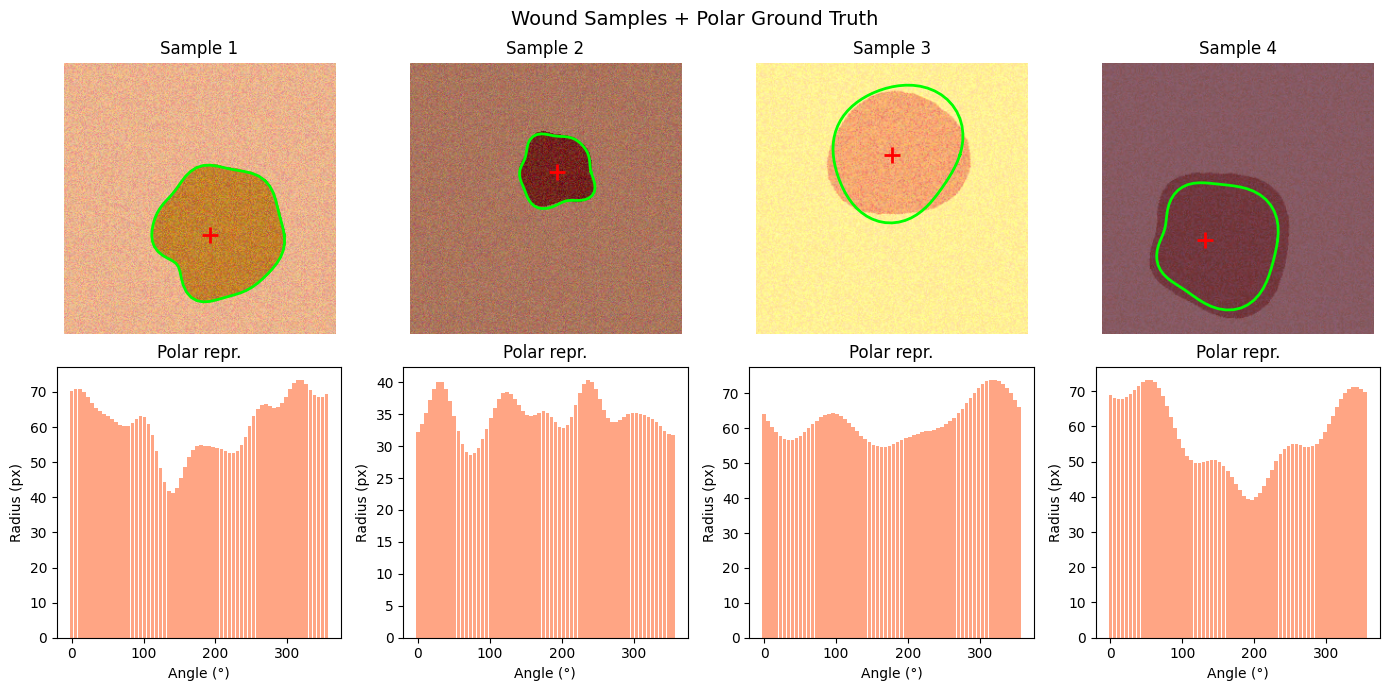

Saved figures/samples.png


In [7]:
MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    s = train_ds[i]
    img = (s['image'] * STD_T + MEAN_T).permute(1,2,0).numpy().clip(0,1)
    pts = s['points'].numpy() * IMAGE_SIZE
    pts_c = np.vstack([pts, pts[0]])
    cx, cy = s['centroid'].numpy() * IMAGE_SIZE

    axes[0,i].imshow(img)
    axes[0,i].plot(pts_c[:,0], pts_c[:,1], 'lime', lw=2)
    axes[0,i].plot(cx, cy, 'r+', ms=12, mew=2)
    axes[0,i].set_title(f'Sample {i+1}'); axes[0,i].axis('off')

    angles = np.linspace(0, 360, NUM_RADII, endpoint=False)
    axes[1,i].bar(angles, s['radii'].numpy()*IMAGE_SIZE, width=5,
                  color='coral', alpha=0.7)
    axes[1,i].set_xlabel('Angle (°)'); axes[1,i].set_ylabel('Radius (px)')
    axes[1,i].set_title('Polar repr.')

plt.suptitle('Wound Samples + Polar Ground Truth', fontsize=14)
plt.tight_layout()
plt.savefig('figures/samples.png', dpi=150)
plt.show()
print('Saved figures/samples.png')

## 4. Model Architecture

### Shared Encoder: ResNet-50 + Transformer

All three decoder variants share an identical encoder — the only variable is the decoder head.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SHARED ENCODER  —  ResNet-50 backbone + lightweight Transformer
# ─────────────────────────────────────────────────────────────────────────────

class CNNTransformerEncoder(nn.Module):
    """
    ResNet-50 feature extractor → flatten spatial tokens → Transformer encoder.
    Output: (B, num_tokens, d_model) memory tensor shared by all decoders.
    """
    def __init__(self, d_model=256, nhead=8, num_layers=2,
                 pretrained=True, dropout=0.1):
        super().__init__()
        backbone = models.resnet50(weights='DEFAULT' if pretrained else None)
        # Use up to layer3 (stride 16) → 16×16 feature map for 256×256 input
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3,
        )  # out: (B, 1024, H/16, W/16)

        self.proj = nn.Conv2d(1024, d_model, 1)  # channel projection

        # Learnable positional embedding
        self.pos_embed = nn.Parameter(torch.randn(1, 256, d_model) * 0.02)
        # 256 = (256/16)^2 spatial tokens

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=num_layers)
        self.d_model = d_model

    def forward(self, x):
        feat = self.backbone(x)              # (B, 1024, 16, 16)
        feat = self.proj(feat)               # (B, d_model, 16, 16)
        B, C, H, W = feat.shape
        tokens = feat.flatten(2).transpose(1, 2)  # (B, HW, d_model)
        tokens = tokens + self.pos_embed[:, :tokens.size(1)]
        memory = self.transformer(tokens)    # (B, HW, d_model)
        return memory


print('CNNTransformerEncoder defined.')
# Quick shape check
with torch.no_grad():
    enc = CNNTransformerEncoder(pretrained=False)
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE)
    out = enc(dummy)
    print(f'Encoder output: {out.shape}  (expect [2, 256, 256])')

CNNTransformerEncoder defined.
Encoder output: torch.Size([2, 256, 256])  (expect [2, 256, 256])


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# DECODER 1 — POLAR  (thesis contribution)
# Directly regresses centroid + radii in polar coordinates
# Loss = L_centroid + L_radii + L_points (converted back to Cartesian)
# ─────────────────────────────────────────────────────────────────────────────

class PolarDecoder(nn.Module):
    """Direct polar regression: predicts (cx, cy, r_0..r_{N-1})."""
    def __init__(self, d_model=256, num_radii=NUM_RADII):
        super().__init__()
        self.num_radii = num_radii
        self.pool = nn.AdaptiveAvgPool1d(1)   # global avg over tokens
        self.head = nn.Sequential(
            nn.Linear(d_model, 512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 256),     nn.ReLU(),
            nn.Linear(256, 2 + num_radii),  # cx, cy, r_0..r_{N-1}
        )
        self._angles = nn.Parameter(
            torch.linspace(0, 2*math.pi, num_radii, dtype=torch.float32),
            requires_grad=False,
        )

    def forward(self, memory):
        # memory: (B, T, d_model)
        z = self.pool(memory.transpose(1,2)).squeeze(-1)   # (B, d_model)
        out = self.head(z)                                  # (B, 2+num_radii)
        cx  = torch.sigmoid(out[:, 0:1])                   # (B, 1)
        cy  = torch.sigmoid(out[:, 1:2])
        r   = torch.sigmoid(out[:, 2:]) * 0.5             # (B, num_radii)
        # Convert to Cartesian boundary points
        ang = self._angles.unsqueeze(0)                    # (1, num_radii)
        px  = cx + r * torch.cos(ang)
        py  = cy + r * torch.sin(ang)
        pts = torch.stack([px, py], dim=-1)                # (B, num_radii, 2)
        return {'centroid': torch.cat([cx, cy], dim=1),
                'radii': r, 'points': pts}


# ─────────────────────────────────────────────────────────────────────────────
# DECODER 2 — DETR-style
# Learnable queries + cross-attention over encoder memory → point predictions
# ─────────────────────────────────────────────────────────────────────────────

class DETRDecoder(nn.Module):
    """Cross-attention decoder predicting boundary point set + centroid."""
    def __init__(self, d_model=256, nhead=8, num_layers=3,
                 num_points=NUM_RADII, dropout=0.1):
        super().__init__()
        self.num_points = num_points
        self.queries = nn.Embedding(num_points + 1, d_model)  # +1 for centroid
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerDecoder(decoder_layer,
                                                  num_layers=num_layers)
        self.point_head    = nn.Linear(d_model, 2)
        self.centroid_head = nn.Linear(d_model, 2)
        self.radii_head    = nn.Linear(d_model, 1)
        self._angles = nn.Parameter(
            torch.linspace(0, 2*math.pi, num_points, dtype=torch.float32),
            requires_grad=False,
        )

    def forward(self, memory):
        B = memory.size(0)
        q = self.queries.weight.unsqueeze(0).expand(B, -1, -1)  # (B, N+1, d)
        out = self.transformer(q, memory)                         # (B, N+1, d)
        pts      = torch.sigmoid(self.point_head(out[:, 1:]))    # (B, N, 2)
        centroid = torch.sigmoid(self.centroid_head(out[:, 0]))  # (B, 2)
        # Radii from Cartesian distance to centroid
        c = centroid.unsqueeze(1)  # (B, 1, 2)
        diff = pts - c
        r = torch.sqrt((diff**2).sum(-1) + 1e-8)                 # (B, N)
        return {'centroid': centroid, 'radii': r, 'points': pts}


# ─────────────────────────────────────────────────────────────────────────────
# DECODER 3 — AUTOREGRESSIVE
# GRU unrolled over angle steps — predicts one radius per step
# ─────────────────────────────────────────────────────────────────────────────

class AutoregressiveDecoder(nn.Module):
    """GRU-based sequential decoder predicting one radius per time step."""
    def __init__(self, d_model=256, hidden=512, num_radii=NUM_RADII):
        super().__init__()
        self.num_radii = num_radii
        self.context   = nn.Linear(d_model, hidden)   # memory → init hidden
        self.gru       = nn.GRUCell(input_size=1, hidden_size=hidden)
        self.out_head  = nn.Linear(hidden, 1)
        self.centroid_head = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 2)
        )
        self._angles = nn.Parameter(
            torch.linspace(0, 2*math.pi, num_radii, dtype=torch.float32),
            requires_grad=False,
        )

    def forward(self, memory):
        B = memory.size(0)
        z = memory.mean(1)                             # (B, d_model) global ctx
        h = torch.tanh(self.context(z))               # (B, hidden)
        centroid = torch.sigmoid(self.centroid_head(z))

        radii_list = []
        x = torch.zeros(B, 1, device=memory.device)   # start token
        for _ in range(self.num_radii):
            h = self.gru(x, h)
            r = torch.sigmoid(self.out_head(h)) * 0.5  # (B, 1)
            radii_list.append(r)
            x = r.detach()    # teacher forcing off → autoregressive
        radii = torch.cat(radii_list, dim=1)           # (B, num_radii)

        ang  = self._angles.unsqueeze(0)
        cx   = centroid[:, 0:1]
        cy   = centroid[:, 1:2]
        pts  = torch.stack([cx + radii * torch.cos(ang),
                            cy + radii * torch.sin(ang)], dim=-1)  # (B, N, 2)
        return {'centroid': centroid, 'radii': radii, 'points': pts}


print('All 3 decoders defined.')
# Shape sanity check
with torch.no_grad():
    enc = CNNTransformerEncoder(pretrained=False)
    mem = enc(torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE))
    for Cls, name in [(PolarDecoder,'Polar'), (DETRDecoder,'DETR'),
                      (AutoregressiveDecoder,'AR')]:
        dec  = Cls()
        pred = dec(mem)
        print(f'{name:15s}  centroid={tuple(pred["centroid"].shape)}'
              f'  radii={tuple(pred["radii"].shape)}'
              f'  points={tuple(pred["points"].shape)}')

All 3 decoders defined.
Polar            centroid=(2, 2)  radii=(2, 64)  points=(2, 64, 2)
DETR             centroid=(2, 2)  radii=(2, 64)  points=(2, 64, 2)
AR               centroid=(2, 2)  radii=(2, 64)  points=(2, 64, 2)


## 5. Loss Functions

In [10]:
def polar_loss(pred, batch, w_centroid=1.0, w_radii=1.0, w_points=0.5):
    """Combined loss for polar boundary regression.

    L = w_c * L_centroid + w_r * L_radii + w_p * L_points
    All terms are MSE; L_points adds spatial consistency.
    """
    gt_c = batch['centroid'].to(device)
    gt_r = batch['radii'].to(device)
    gt_p = batch['points'].to(device)

    l_c = F.mse_loss(pred['centroid'], gt_c)
    l_r = F.mse_loss(pred['radii'],    gt_r)
    l_p = F.mse_loss(pred['points'],   gt_p)

    total = w_centroid*l_c + w_radii*l_r + w_points*l_p
    return total, {'loss_centroid': l_c.item(),
                   'loss_radii'   : l_r.item(),
                   'loss_points'  : l_p.item()}


def compute_iou(pred_pts, gt_pts, size=IMAGE_SIZE):
    """Polygon IoU via rasterisation (batch, averaged)."""
    from PIL import Image as PILImage, ImageDraw
    ious = []
    for pp, gp in zip(pred_pts.cpu().numpy(), gt_pts.cpu().numpy()):
        pp_px = (pp * size).astype(np.int32)
        gp_px = (gp * size).astype(np.int32)
        pm = PILImage.new('L', (size,size))
        gm = PILImage.new('L', (size,size))
        ImageDraw.Draw(pm).polygon([tuple(p) for p in pp_px], fill=1)
        ImageDraw.Draw(gm).polygon([tuple(p) for p in gp_px], fill=1)
        pa = np.array(pm); ga = np.array(gm)
        inter = float((pa & ga).sum())
        union = float((pa | ga).sum())
        ious.append(inter / union if union > 0 else 0.0)
    return float(np.mean(ious))

print('Loss functions defined.')

Loss functions defined.


## 6. Extended Training Loop (Fine-tune with Strong Augmentation)

In [11]:
from torch.cuda.amp import autocast, GradScaler

def train_extended(decoder_name, DecoderClass, output_dir,
                   pretrained_path=None,
                   max_epochs=30, patience=10, lr=3e-5,
                   pretrained_backbone=True):
    """Fine-tune from a pretrained checkpoint with stronger augmentation.
    
    This loads weights from a previous basic-augmentation run and continues
    training with aggressive augmentation for better generalization.
    Lower LR (3e-5 vs 1e-4) to avoid catastrophic forgetting.
    """
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    encoder = CNNTransformerEncoder(pretrained=pretrained_backbone).to(device)
    decoder = DecoderClass().to(device)

    # --- Load pretrained weights from basic run ---
    if pretrained_path and Path(pretrained_path).exists():
        print(f'  Loading pretrained weights from: {pretrained_path}')
        ckpt = torch.load(pretrained_path, map_location=device, weights_only=False)
        encoder.load_state_dict(ckpt['encoder_state'])
        decoder.load_state_dict(ckpt['decoder_state'])
        base_epoch = ckpt.get('epoch', 0)
        base_val = ckpt.get('val_loss', '?')
        print(f'  Base model: epoch {base_epoch}, val_loss={base_val}')
    else:
        print(f'  WARNING: No pretrained path found at {pretrained_path}')
        print(f'  Training from scratch with strong augmentation.')

    params  = list(encoder.parameters()) + list(decoder.parameters())
    opt     = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(
                  opt, T_max=max_epochs, eta_min=lr*0.01)

    scaler = GradScaler()

    history = {
        'train_loss': [], 'val_loss': [],
        'loss_centroid': [], 'loss_radii': [], 'loss_points': [],
    }
    best_val  = float('inf')
    patience_counter = 0
    best_epoch = 0

    print(f'\n{"="*60}')
    print(f'  EXTENDED Training: {decoder_name.upper()}')
    print(f'  Fine-tuning with strong augmentation (skin tone + geometry)')
    print(f'  Epochs: 1 -> {max_epochs} | LR: {lr} | Patience: {patience}')
    print(f'  Mixed Precision: ENABLED')
    print(f'{"="*60}')

    enc_params = sum(p.numel() for p in encoder.parameters())
    dec_params = sum(p.numel() for p in decoder.parameters())
    print(f'  Encoder params: {enc_params:,}')
    print(f'  Decoder params: {dec_params:,}')
    print(f'  Total params:   {enc_params + dec_params:,}')

    for epoch in range(1, max_epochs + 1):
        # --- Train ---
        encoder.train(); decoder.train()
        train_losses = []
        for batch in train_dl:
            opt.zero_grad()
            with autocast():
                mem  = encoder(batch['image'].to(device))
                pred = decoder(mem)
                loss, _ = polar_loss(pred, batch)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(params, 1.0)
            scaler.step(opt)
            scaler.update()
            train_losses.append(loss.item())
        sched.step()

        # --- Validate ---
        encoder.eval(); decoder.eval()
        val_losses, comp_losses = [], []
        with torch.no_grad():
            for batch in val_dl:
                with autocast():
                    mem  = encoder(batch['image'].to(device))
                    pred = decoder(mem)
                    loss, comps = polar_loss(pred, batch)
                val_losses.append(loss.item())
                comp_losses.append(comps)

        tl = float(np.mean(train_losses))
        vl = float(np.mean(val_losses))
        mean_comps = {k: float(np.mean([c[k] for c in comp_losses]))
                      for k in comp_losses[0]}

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        for k in ['loss_centroid', 'loss_radii', 'loss_points']:
            history[k].append(mean_comps[k])

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Ep {epoch:03d}/{max_epochs}  '
                  f'train={tl:.4f}  val={vl:.4f}  '
                  f'lr={opt.param_groups[0]["lr"]:.2e}')

        # --- Save best model ---
        if vl < best_val:
            best_val   = vl
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                'encoder_state': encoder.state_dict(),
                'decoder_state': decoder.state_dict(),
                'epoch': epoch, 'val_loss': vl,
            }, out / 'best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stop at epoch {epoch} (best={best_epoch})')
                break

        if epoch % 10 == 0:
            torch.save({
                'encoder_state': encoder.state_dict(),
                'decoder_state': decoder.state_dict(),
                'optimizer_state': opt.state_dict(),
                'epoch': epoch,
                'best_val_loss': best_val,
                'best_epoch': best_epoch,
                'history': history,
            }, out / 'checkpoint_latest.pth')
            print(f'  [Checkpoint saved at epoch {epoch}]')

    with open(out / 'history.json', 'w') as f:
        json.dump(history, f)

    print(f'  Best val loss: {best_val:.4f} at epoch {best_epoch}')
    return history, best_epoch


print('Extended training loop defined (fine-tune with strong augmentation).')

Extended training loop defined (fine-tune with strong augmentation).


## 7. Fine-tune Autoregressive Decoder

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# EXTENDED: Fine-tune AUTOREGRESSIVE with strong augmentation
# ══════════════════════════════════════════════════════════════════════════════
# Loads best.pth from basic run, then fine-tunes with:
# - Rotation, vertical flip, scale
# - HSV skin tone augmentation (Fitzpatrick I-VI)
# - Gaussian noise + blur
# Lower LR (3e-5) to preserve learned features while adapting to diversity.

import time
import glob as _glob
t_start = time.time()

# Find the pretrained checkpoint from the basic ablation run
# On Kaggle: attach the basic run output as a dataset input
PRETRAINED_CANDIDATES = [
    # Local (if basic run output is in same working dir)
    'results/ablation/autoregressive/best.pth',
    # Kaggle dataset: save basic run output with slug 'ablation-basic-autoregressive'
    '/kaggle/input/ablation-basic-autoregressive/results/ablation/autoregressive/best.pth',
    '/kaggle/input/ablation-basic-autoregressive/best.pth',
    # Glob fallbacks
    *_glob.glob('/kaggle/input/*ablation*autoregressive*/results/ablation/autoregressive/best.pth'),
    *_glob.glob('/kaggle/input/*ablation*autoregressive*/best.pth'),
    *_glob.glob('/kaggle/input/*/results/ablation/autoregressive/best.pth'),
]
pretrained_path = None
for p in PRETRAINED_CANDIDATES:
    if Path(p).exists():
        pretrained_path = p
        print(f'Found pretrained checkpoint: {p}')
        break

if pretrained_path is None:
    print('WARNING: No pretrained checkpoint found. Will train from scratch.')
    print('  To use pretrained weights, attach the basic ablation output as a Kaggle dataset input.')

history, conv_ep = train_extended(
    decoder_name = 'autoregressive',
    DecoderClass = AutoregressiveDecoder,
    output_dir   = 'results/ablation/autoregressive_extended',
    pretrained_path = pretrained_path,
    max_epochs   = 30,
    patience     = 10,
    lr           = 3e-5,
    pretrained_backbone = True,
)

t_elapsed = time.time() - t_start
print(f'\nTotal training time: {t_elapsed/60:.1f} min ({t_elapsed/3600:.2f} h)')
print(f'Convergence epoch: {conv_ep}')

  To use pretrained weights, attach the basic ablation output as a Kaggle dataset input.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 396MB/s]


  Training from scratch with strong augmentation.

  EXTENDED Training: AUTOREGRESSIVE
  Fine-tuning with strong augmentation (skin tone + geometry)
  Epochs: 1 -> 30 | LR: 3e-05 | Patience: 10
  Mixed Precision: ENABLED
  Encoder params: 10,450,752
  Decoder params: 956,355
  Total params:   11,407,107
  Ep 001/30  train=0.0136  val=0.0056  lr=2.99e-05
  Ep 005/30  train=0.0022  val=0.0018  lr=2.80e-05
  Ep 010/30  train=0.0019  val=0.0016  lr=2.26e-05
  [Checkpoint saved at epoch 10]
  Ep 015/30  train=0.0018  val=0.0015  lr=1.52e-05
  Ep 020/30  train=0.0017  val=0.0015  lr=7.73e-06
  [Checkpoint saved at epoch 20]
  Ep 025/30  train=0.0017  val=0.0014  lr=2.29e-06
  Ep 030/30  train=0.0017  val=0.0014  lr=3.00e-07
  [Checkpoint saved at epoch 30]
  Best val loss: 0.0014 at epoch 30

Total training time: 375.6 min (6.26 h)
Convergence epoch: 30


## 8. Evaluation on Test Set

In [13]:
def evaluate_variant(name, DecoderClass, results_dir):
    ckpt_path = Path(results_dir) / 'best.pth'
    if not ckpt_path.exists():
        print(f'No checkpoint at {ckpt_path}'); return None

    encoder = CNNTransformerEncoder(pretrained=False).to(device)
    decoder = DecoderClass().to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    encoder.load_state_dict(ckpt['encoder_state'])
    decoder.load_state_dict(ckpt['decoder_state'])
    encoder.eval(); decoder.eval()

    chamfers, ious, inference_times = [], [], []
    with torch.no_grad():
        for batch in tqdm(test_dl, desc=f'Evaluating {name}'):
            t0 = time.time()
            mem  = encoder(batch['image'].to(device))
            pred = decoder(mem)
            inference_times.append((time.time() - t0) / batch['image'].shape[0] * 1000)

            pp = pred['points'].cpu().numpy() * IMAGE_SIZE
            gp = batch['points'].numpy()      * IMAGE_SIZE
            for p, g in zip(pp, gp):
                d_pg = np.min(np.linalg.norm(p[:,None] - g[None,:], axis=-1), axis=1)
                d_gp = np.min(np.linalg.norm(g[:,None] - p[None,:], axis=-1), axis=1)
                chamfers.append((d_pg.mean() + d_gp.mean()) / 2)
            ious.append(compute_iou(pred['points'], batch['points']))

    return {
        'chamfer': {'mean': float(np.mean(chamfers)), 'std': float(np.std(chamfers))},
        'iou'    : {'mean': float(np.mean(ious)),     'std': float(np.std(ious))},
        'inference_ms': {'mean': float(np.mean(inference_times)), 'std': float(np.std(inference_times))},
    }

print('Evaluating autoregressive (extended) on test set...')
result = evaluate_variant('autoregressive_extended', AutoregressiveDecoder, 'results/ablation/autoregressive_extended')
if result:
    print(f'  Chamfer: {result["chamfer"]["mean"]:.2f} +/- {result["chamfer"]["std"]:.2f} px')
    print(f'  IoU:     {result["iou"]["mean"]:.3f} +/- {result["iou"]["std"]:.3f}')
    print(f'  Inference: {result["inference_ms"]["mean"]:.1f} ms/sample')
    with open('results/ablation/autoregressive_extended/test_results.json', 'w') as f:
        json.dump(result, f, indent=2)
    print('  Results saved.')

Evaluating autoregressive (extended) on test set...


Evaluating autoregressive_extended: 100%|██████████| 250/250 [02:52<00:00,  1.45it/s]

  Chamfer: 4.78 +/- 1.76 px
  IoU:     0.843 +/- 0.015
  Inference: 84.6 ms/sample
  Results saved.


## 9. Figures

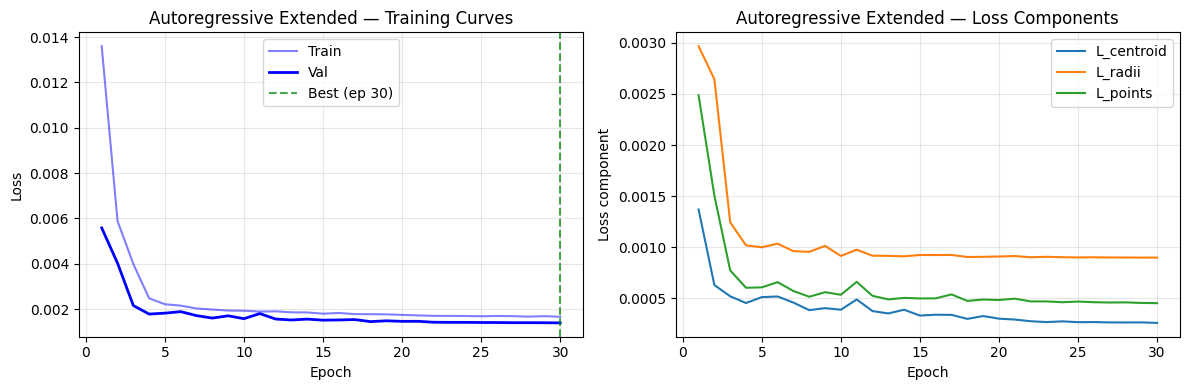

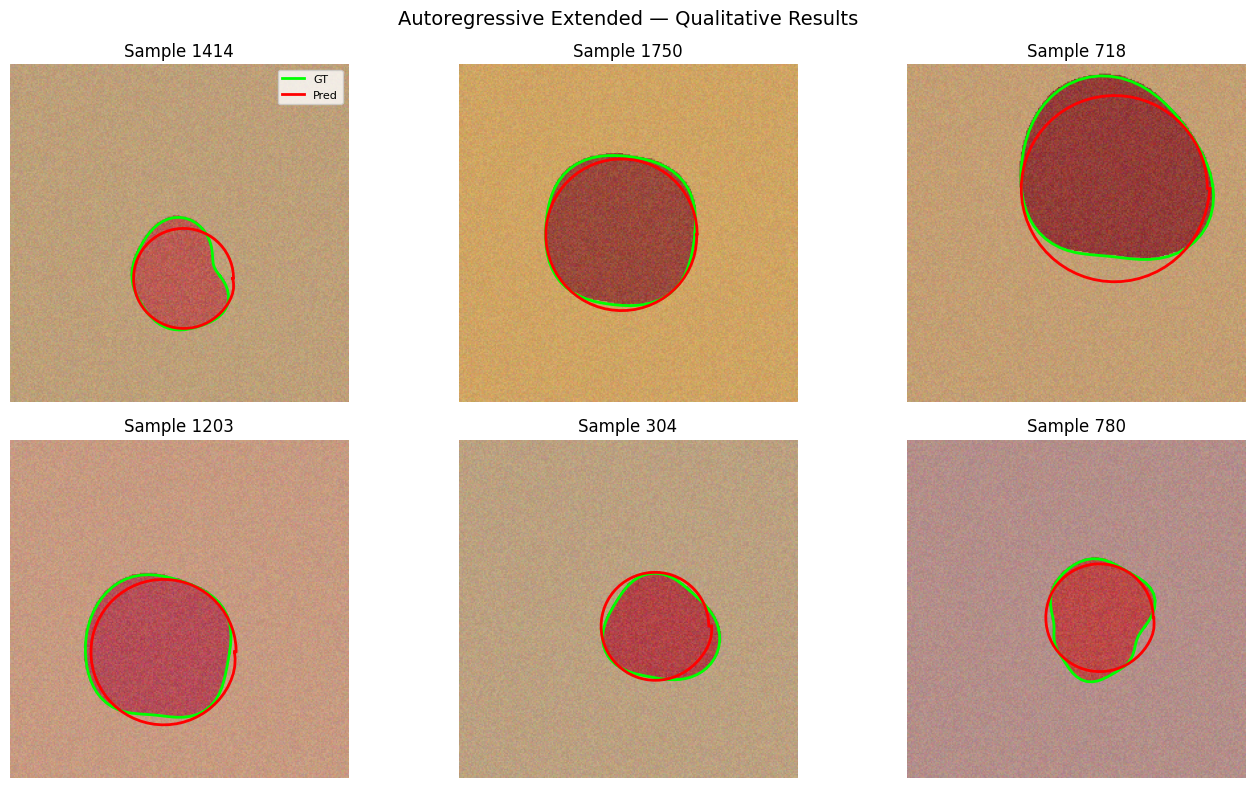

Figures saved.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ep = range(1, len(history['train_loss'])+1)
ax1.plot(ep, history['train_loss'], 'b-', alpha=0.5, label='Train')
ax1.plot(ep, history['val_loss'],   'b-', lw=2,      label='Val')
ax1.axvline(conv_ep, color='green', ls='--', alpha=0.7, label=f'Best (ep {conv_ep})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Autoregressive Extended — Training Curves')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history['loss_centroid'], label='L_centroid')
ax2.plot(ep, history['loss_radii'],    label='L_radii')
ax2.plot(ep, history['loss_points'],   label='L_points')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss component')
ax2.set_title('Autoregressive Extended — Loss Components')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/ablation_autoregressive_extended_curves.png', dpi=150)
plt.show()

# ── Qualitative ──────────────────────────────────────────────────────────────
ckpt_p = Path('results/ablation/autoregressive_extended/best.pth')
if ckpt_p.exists():
    enc = CNNTransformerEncoder(pretrained=False).to(device)
    dec = AutoregressiveDecoder().to(device)
    ck  = torch.load(ckpt_p, map_location=device, weights_only=False)
    enc.load_state_dict(ck['encoder_state'])
    dec.load_state_dict(ck['decoder_state'])
    enc.eval(); dec.eval()

    NUM_SHOW = 6
    fig, axes = plt.subplots(2, NUM_SHOW//2, figsize=(14, 8))
    axes = axes.flatten()
    np.random.seed(99)
    idxs = np.random.choice(len(test_ds), NUM_SHOW, replace=False)

    for ax_i, idx in enumerate(idxs):
        s   = test_ds[idx]
        img = (s['image'] * STD_T + MEAN_T).permute(1,2,0).numpy().clip(0,1)
        gt  = s['points'].numpy() * IMAGE_SIZE
        gtc = np.vstack([gt, gt[0]])

        with torch.no_grad():
            mem  = enc(s['image'].unsqueeze(0).to(device))
            pred = dec(mem)
        pts = pred['points'][0].cpu().numpy() * IMAGE_SIZE
        ptc = np.vstack([pts, pts[0]])

        axes[ax_i].imshow(img)
        axes[ax_i].plot(gtc[:,0], gtc[:,1], 'lime', lw=2, label='GT')
        axes[ax_i].plot(ptc[:,0], ptc[:,1], 'red',  lw=2, label='Pred')
        axes[ax_i].set_title(f'Sample {idx}'); axes[ax_i].axis('off')
        if ax_i == 0: axes[ax_i].legend(fontsize=8)

    plt.suptitle('Autoregressive Extended — Qualitative Results', fontsize=14)
    plt.tight_layout()
    plt.savefig('figures/ablation_autoregressive_extended_qualitative.png', dpi=150)
    plt.show()

print('Figures saved.')

## 10. Output Summary

In [15]:
print('\n' + '='*60)
print('  EXTENDED RUN COMPLETE')
print('='*60)
for f in ['results/ablation/autoregressive_extended/best.pth',
          'results/ablation/autoregressive_extended/history.json',
          'results/ablation/autoregressive_extended/test_results.json',
          'figures/ablation_autoregressive_extended_curves.png',
          'figures/ablation_autoregressive_extended_qualitative.png']:
    exists = 'OK' if Path(f).exists() else 'MISSING'
    print(f'  [{exists}] {f}')
print('\nDone!')


  EXTENDED RUN COMPLETE
  [OK] results/ablation/autoregressive_extended/best.pth
  [OK] results/ablation/autoregressive_extended/history.json
  [OK] results/ablation/autoregressive_extended/test_results.json
  [OK] figures/ablation_autoregressive_extended_curves.png
  [OK] figures/ablation_autoregressive_extended_qualitative.png

Done!
